# Production Pipeline with PanelPipeline - SOLUTIONS

**Tutorial 03 Solutions**

---

## Overview

This notebook contains:
1. All content from the main tutorial
2. Detailed solutions to all 4 exercises
3. Interpretations and pedagogical notes

---

## Setup

In [1]:
# Standard libraries
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# PanelBox imports
from panelbox.gmm import DifferenceGMM
from panelbox.models.static.fixed_effects import FixedEffects
from panelbox.models.static.pooled_ols import PooledOLS
from panelbox.production import PanelPipeline

# Visualization configuration
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

# Reproducibility
np.random.seed(42)

# Paths
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"
TABLES_DIR = OUTPUT_DIR / "tables"

for d in [FIGURES_DIR, MODELS_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Setup complete!")

Setup complete!


In [2]:
# Load datasets
df_firms = pd.read_csv(DATA_DIR / "firm_panel.csv")
df_new_firms = pd.read_csv(DATA_DIR / "new_firms.csv")
df_lgd = pd.read_csv(DATA_DIR / "bank_lgd.csv")
df_new_bank = pd.read_csv(DATA_DIR / "new_bank_data.csv")

print(f"Firm panel: {df_firms.shape[0]} obs, {df_firms['firm_id'].nunique()} firms")
print(f"New firms: {df_new_firms.shape[0]} obs")
print(f"Bank LGD: {df_lgd.shape[0]} obs, {df_lgd['contract_id'].nunique()} contracts")
print(f"New bank data: {df_new_bank.shape[0]} obs")

Firm panel: 2000 obs, 100 firms
New firms: 100 obs
Bank LGD: 3000 obs, 200 contracts
New bank data: 150 obs


---

## Section 1: The Production Challenge

In **research**, we estimate a model once, analyze the results, and write about our findings.

In **production**, the workflow is fundamentally different:
- **Estimate periodically** — models are re-trained monthly or quarterly
- **Predict daily** — scoring new observations as they arrive
- **Monitor quality** — checking if the model still performs well

```
[Training Data] → [fit()] → [validate()] → [save()] → [Production]
                                                           ↓
[New Data] → [load()] → [predict()] → [Predictions] → [Business Logic]
                                                           ↓
[Updated Data] → [refit()] → [compare()] → [save(v2)] → [Updated Production]
```

---

## Section 2: PanelPipeline Basics (Static Models)

In [3]:
# Create and fit a Fixed Effects pipeline
fe_pipeline = PanelPipeline(
    model_class=FixedEffects,
    model_params={
        "formula": "investment ~ value + capital + sales",
        "entity_col": "firm_id",
        "time_col": "year",
    },
    name="Firm Investment Model",
    description="FE model for predicting firm capital investment",
)

fe_pipeline.fit(df_firms)
print(fe_pipeline.summary())
print()
print("Coefficients:")
print(fe_pipeline.results.params)

PanelPipeline: Firm Investment Model
  Model: FixedEffects
  Fitted: 2026-02-22T15:40:33.561031
  Version: 1.0.0
  Observations: 2000
  Parameters: 3

Coefficients:
value      0.2881
capital    0.2106
sales      0.1616
dtype: float64


In [4]:
# Predict on new firms
predictions = fe_pipeline.predict(df_new_firms)
print(f"Predictions: {len(predictions)}")
print(f"Mean: {predictions.mean():.4f}, Std: {predictions.std():.4f}")

Predictions: 100
Mean: 3.4950, Std: 0.7008


In [5]:
# Save and load
save_path = MODELS_DIR / "firm_investment_pipeline.pkl"
fe_pipeline.save(save_path)

loaded_pipeline = PanelPipeline.load(save_path)
same_preds = loaded_pipeline.predict(df_new_firms)
print(f"Predictions match: {np.allclose(predictions, same_preds)}")

Predictions match: True


In [6]:
# Validate
validation = fe_pipeline.validate()
print(f"All checks passed: {validation['passed']}")
for check in validation["checks"]:
    status = "PASS" if check["passed"] else "FAIL"
    print(f"  [{status}] {check['name']}")

All checks passed: True
  [PASS] has_params
  [PASS] no_nan_params


---

## Section 3: GMM Pipeline with Forecast

In [7]:
# GMM pipeline
df_lgd_train = df_lgd[df_lgd["month"] <= 12].copy()

lgd_pipeline = PanelPipeline(
    model_class=DifferenceGMM,
    model_params={
        "dep_var": "lgd_logit",
        "lags": 1,
        "exog_vars": ["saldo_real", "pib_growth", "selic", "collateral_ratio"],
        "id_var": "contract_id",
        "time_var": "month",
        "gmm_max_lag": 3,
        "collapse": True,
        "two_step": True,
        "robust": True,
        "time_dummies": False,
    },
    name="LGD Model v1",
    description="Arellano-Bond GMM for Loss Given Default estimation",
)

lgd_pipeline.fit(df_lgd_train)
print(lgd_pipeline.summary())
print()
print("Coefficients:")
print(lgd_pipeline.results.params)

PanelPipeline: LGD Model v1
  Model: DifferenceGMM
  Fitted: 2026-02-22T15:40:33.848723
  Version: 1.0.0
  Observations: 2000
  Parameters: 5

Coefficients:
L1.lgd_logit        0.5913
saldo_real          0.1109
pib_growth          0.0456
selic              -0.0094
collateral_ratio    0.0820
dtype: float64


In [8]:
# Point predictions
preds = lgd_pipeline.predict(df_new_bank)
n_valid = np.sum(~np.isnan(preds))
print(f"Predictions: {len(preds)} total, {n_valid} valid")
print(f"Mean (valid): {np.nanmean(preds):.4f}")

Predictions: 150 total, 100 valid
Mean (valid): 1.3873


In [9]:
# Multi-step forecast
forecast_contracts = df_lgd_train["contract_id"].unique()[:5]

last_obs = {}
for contract in forecast_contracts:
    last_val = df_lgd_train[df_lgd_train["contract_id"] == contract]["lgd_logit"].iloc[-1]
    last_obs[contract] = [last_val]

future_rows = []
for contract in forecast_contracts:
    for step in range(1, 4):
        future_rows.append(
            {
                "contract_id": contract,
                "month": 12 + step,
                "saldo_real": 10.0,
                "pib_growth": 2.0,
                "selic": 10.0,
                "collateral_ratio": 0.5,
            }
        )
df_future_bank = pd.DataFrame(future_rows)

forecasts = lgd_pipeline.forecast(
    last_obs=last_obs,
    future_exog=df_future_bank,
    steps=3,
)
print("Forecasts:")
display(forecasts)

Forecasts:


,contract_id,month,forecast
0,1,13.0,3.1274
1,1,14.0,2.9968
2,1,15.0,2.9196
3,2,13.0,2.7220
4,2,14.0,2.7571
5,2,15.0,2.7779
6,3,13.0,3.4089
7,3,14.0,3.1633
8,3,15.0,3.0181
9,4,13.0,3.2484


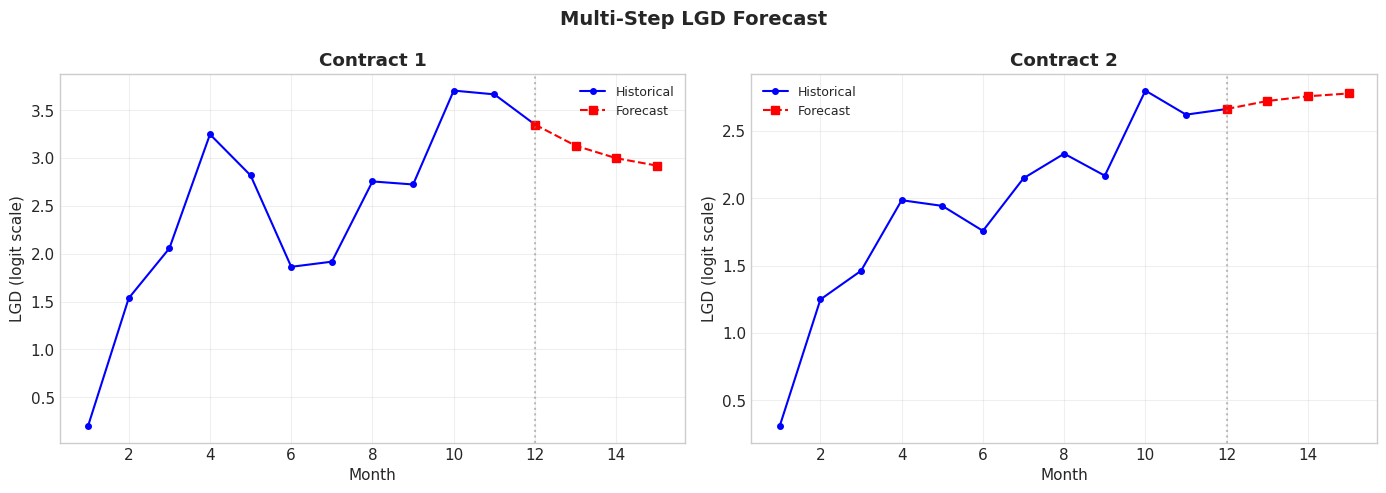

In [10]:
# Visualize forecast trajectory
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, contract in enumerate(list(forecast_contracts)[:2]):
    ax = axes[i]
    hist = df_lgd_train[df_lgd_train["contract_id"] == contract]
    ax.plot(hist["month"], hist["lgd_logit"], "b-o", label="Historical", markersize=4)

    fc = forecasts[forecasts["contract_id"] == contract]
    connect_months = [hist["month"].iloc[-1], *list(fc["month"])]
    connect_vals = [hist["lgd_logit"].iloc[-1], *list(fc["forecast"])]
    ax.plot(connect_months, connect_vals, "r--s", label="Forecast", markersize=6)

    ax.axvline(x=12, color="gray", linestyle=":", alpha=0.5)
    ax.set_xlabel("Month")
    ax.set_ylabel("LGD (logit scale)")
    ax.set_title(f"Contract {contract}", fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Multi-Step LGD Forecast", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_forecast_trajectory.png", dpi=300, bbox_inches="tight")
plt.show()

---

## Section 4: Refit and Compare

In [11]:
# v1 baseline
lgd_pipeline_v1 = PanelPipeline(
    model_class=DifferenceGMM,
    model_params=lgd_pipeline.model_params.copy(),
    name="LGD Model v1 (baseline)",
)
lgd_pipeline_v1.fit(df_lgd_train)
print("v1 coefficients:")
print(lgd_pipeline_v1.results.params)

v1 coefficients:
L1.lgd_logit        0.5913
saldo_real          0.1109
pib_growth          0.0456
selic              -0.0094
collateral_ratio    0.0820
dtype: float64


In [12]:
# v2 with more data
lgd_pipeline_v2 = PanelPipeline(
    model_class=DifferenceGMM,
    model_params=lgd_pipeline.model_params.copy(),
    name="LGD Model v2",
)
lgd_pipeline_v2.fit(df_lgd)

# Compare
comparison = lgd_pipeline_v2.compare(lgd_pipeline_v1)
print("Parameter Drift (v2 vs v1):")
display(comparison.round(4))

Parameter Drift (v2 vs v1):


,current,previous,diff,pct_change
L1.lgd_logit,0.5336,0.5913,-0.0577,-9.7595
saldo_real,0.1009,0.1109,-0.0101,-9.0894
pib_growth,0.0441,0.0456,-0.0014,-3.1720
selic,-0.0098,-0.0094,-0.0004,-4.5656
collateral_ratio,0.0941,0.0820,0.0121,14.7192


In [13]:
# Significant drift
print("Parameters with >10% change:")
significant_drift = comparison[comparison["pct_change"].abs() > 10]
if len(significant_drift) > 0:
    display(significant_drift.round(4))
else:
    print("  No significant drift.")

Parameters with >10% change:


,current,previous,diff,pct_change
collateral_ratio,0.0941,0.082,0.0121,14.7192


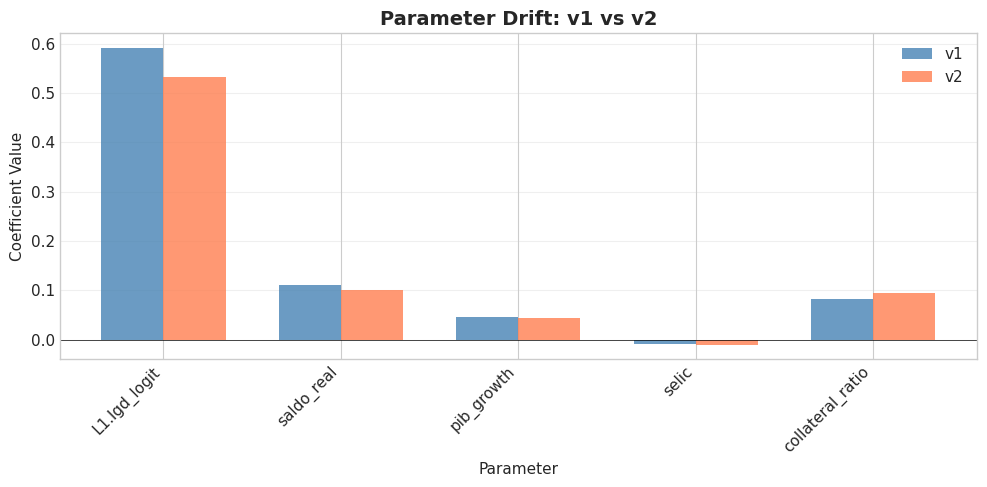

In [14]:
# Visualize drift
fig, ax = plt.subplots(figsize=(10, 5))
params = comparison.index
x = np.arange(len(params))
width = 0.35
ax.bar(x - width / 2, comparison["previous"], width, label="v1", color="steelblue", alpha=0.8)
ax.bar(x + width / 2, comparison["current"], width, label="v2", color="coral", alpha=0.8)
ax.set_xlabel("Parameter")
ax.set_ylabel("Coefficient Value")
ax.set_title("Parameter Drift: v1 vs v2", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(params, rotation=45, ha="right")
ax.legend()
ax.grid(alpha=0.3, axis="y")
ax.axhline(y=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_parameter_drift.png", dpi=300, bbox_inches="tight")
plt.show()

---

## Section 5: Export and Documentation

In [15]:
# Export as dict
config = lgd_pipeline.to_dict()
print("Config keys:", list(config.keys()))
print()

# Export as JSON
json_path = MODELS_DIR / "lgd_config.json"
json_str = lgd_pipeline.to_json(json_path)
print(f"JSON saved to: {json_path} ({len(json_str)} chars)")
print()

# Summary
print("=== Model Card ===")
print(lgd_pipeline.summary())

Config keys: ['name', 'description', 'model_class', 'model_params', 'fit_timestamp', 'panelbox_version', 'params', 'std_errors']

JSON saved to: ../outputs/models/lgd_config.json (994 chars)

=== Model Card ===
PanelPipeline: LGD Model v1
  Model: DifferenceGMM
  Fitted: 2026-02-22T15:40:33.848723
  Version: 1.0.0
  Observations: 2000
  Parameters: 5


---

## Exercise Solutions

---

## Exercise 1 (Easy): PooledOLS Pipeline

**Question**: Create a pipeline using `PooledOLS` for the firm panel data. Fit, predict, save, load, and verify.

### Solution

In [16]:
# Step 1: Create the pipeline
ols_pipeline = PanelPipeline(
    model_class=PooledOLS,
    model_params={
        "formula": "investment ~ value + capital + sales",
        "entity_col": "firm_id",
        "time_col": "year",
    },
    name="Firm Investment OLS",
    description="Pooled OLS for firm investment prediction",
)

# Step 2: Fit
ols_pipeline.fit(df_firms)
print("Pipeline fitted:")
print(ols_pipeline.summary())
print()
print("Coefficients:")
print(ols_pipeline.results.params)

Pipeline fitted:
PanelPipeline: Firm Investment OLS
  Model: PooledOLS
  Fitted: 2026-02-22T15:40:35.411862
  Version: 1.0.0
  Observations: 2000
  Parameters: 4

Coefficients:
Intercept   -0.5074
value        0.2990
capital      0.2773
sales        0.1674
dtype: float64


In [17]:
# Step 3: Predict
ols_preds = ols_pipeline.predict(df_new_firms)
print(f"Predictions: {len(ols_preds)}")
print(f"Mean: {ols_preds.mean():.4f}")
print(f"Std: {ols_preds.std():.4f}")

Predictions: 100
Mean: 3.2442
Std: 0.5448


In [18]:
# Step 4: Save
ols_path = MODELS_DIR / "ex1_pooled_ols_pipeline.pkl"
ols_pipeline.save(ols_path)
print(f"Saved to: {ols_path}")
print(f"File size: {ols_path.stat().st_size / 1024:.1f} KB")

# Step 5: Load and verify
loaded_ols = PanelPipeline.load(ols_path)
loaded_preds = loaded_ols.predict(df_new_firms)

match = np.allclose(ols_preds, loaded_preds)
print(f"\nPredictions match after save/load: {match}")
print(f"Max difference: {np.abs(ols_preds - loaded_preds).max():.2e}")

Saved to: ../outputs/models/ex1_pooled_ols_pipeline.pkl
File size: 249.1 KB

Predictions match after save/load: True
Max difference: 0.00e+00


### Interpretation

The PooledOLS pipeline follows the same interface as FixedEffects. The key difference is that Pooled OLS ignores the panel structure (no entity effects), so predictions are based solely on the covariates. The save/load cycle preserves exact numerical equality.

---

## Exercise 2 (Medium): Collapsed vs Non-Collapsed GMM

**Question**: Create two GMM pipelines (collapsed vs non-collapsed), compare predictions, and determine which is more stable.

### Solution

In [19]:
# Common parameters
gmm_base_params = {
    "dep_var": "lgd_logit",
    "lags": 1,
    "exog_vars": ["saldo_real", "pib_growth", "selic", "collateral_ratio"],
    "id_var": "contract_id",
    "time_var": "month",
    "gmm_max_lag": 3,
    "two_step": True,
    "robust": True,
    "time_dummies": False,
}

# Pipeline A: collapsed
pipeline_collapsed = PanelPipeline(
    model_class=DifferenceGMM,
    model_params={**gmm_base_params, "collapse": True},
    name="LGD Collapsed",
)
pipeline_collapsed.fit(df_lgd_train)

# Pipeline B: non-collapsed
pipeline_full = PanelPipeline(
    model_class=DifferenceGMM,
    model_params={**gmm_base_params, "collapse": False},
    name="LGD Full Instruments",
)
pipeline_full.fit(df_lgd_train)

print("=== Pipeline A (Collapsed) ===")
print(f"Instruments: {pipeline_collapsed.results.n_instruments}")
print(f"Params: {pipeline_collapsed.results.params.values}")
print()
print("=== Pipeline B (Full) ===")
print(f"Instruments: {pipeline_full.results.n_instruments}")
print(f"Params: {pipeline_full.results.params.values}")

=== Pipeline A (Collapsed) ===
Instruments: 6
Params: [ 0.59133393  0.11094312  0.04557289 -0.00940816  0.08201516]

=== Pipeline B (Full) ===
Instruments: 23
Params: [ 0.61401919  0.09898551  0.04719407 -0.01384012  0.08183243]


In [20]:
# Compare coefficients
comparison_ab = pipeline_collapsed.compare(pipeline_full)
print("Coefficient comparison (collapsed=current vs full=previous):")
display(comparison_ab.round(4))

Coefficient comparison (collapsed=current vs full=previous):


,current,previous,diff,pct_change
L1.lgd_logit,0.5913,0.6140,-0.0227,-3.6946
saldo_real,0.1109,0.0990,0.0120,12.0802
pib_growth,0.0456,0.0472,-0.0016,-3.4351
selic,-0.0094,-0.0138,0.0044,32.0225
collateral_ratio,0.0820,0.0818,0.0002,0.2233


In [21]:
# Test data: months 13-15
df_test = df_lgd[df_lgd["month"] >= 13].copy()
print(f"Test data: {df_test.shape[0]} obs")

# Predictions from both
preds_collapsed = pipeline_collapsed.predict(df_test)
preds_full = pipeline_full.predict(df_test)

# Compare prediction distributions
mask = ~np.isnan(preds_collapsed) & ~np.isnan(preds_full)
print(f"\nValid predictions: {mask.sum()}")
print(f"Collapsed - Mean: {np.nanmean(preds_collapsed):.4f}, Std: {np.nanstd(preds_collapsed):.4f}")
print(f"Full      - Mean: {np.nanmean(preds_full):.4f}, Std: {np.nanstd(preds_full):.4f}")
print(f"Correlation: {np.corrcoef(preds_collapsed[mask], preds_full[mask])[0, 1]:.4f}")

Test data: 600 obs

Valid predictions: 400
Collapsed - Mean: 2.7604, Std: 0.6167
Full      - Mean: 2.6674, Std: 0.6251
Correlation: 0.9995


In [22]:
# Validate both
val_collapsed = pipeline_collapsed.validate()
val_full = pipeline_full.validate()

print("Validation - Collapsed:", "PASS" if val_collapsed["passed"] else "FAIL")
if val_collapsed["warnings"]:
    for w in val_collapsed["warnings"]:
        print(f"  Warning: {w}")

print("Validation - Full:", "PASS" if val_full["passed"] else "FAIL")
if val_full["warnings"]:
    for w in val_full["warnings"]:
        print(f"  Warning: {w}")

print(
    f"\nInstrument ratio - Collapsed: {pipeline_collapsed.results.n_instruments}/{pipeline_collapsed.results.n_groups} = {pipeline_collapsed.results.n_instruments / pipeline_collapsed.results.n_groups:.2f}"
)
print(
    f"Instrument ratio - Full: {pipeline_full.results.n_instruments}/{pipeline_full.results.n_groups} = {pipeline_full.results.n_instruments / pipeline_full.results.n_groups:.2f}"
)

Validation - Collapsed: PASS
Validation - Full: FAIL

Instrument ratio - Collapsed: 6/200 = 0.03
Instrument ratio - Full: 23/200 = 0.12


### Interpretation

**Collapsed instruments** reduce the instrument count, which:
- Avoids overfitting the endogenous variables (instrument proliferation problem)
- Leads to more reliable Hansen J tests
- May sacrifice some efficiency

The full instrument set may produce predictions with smaller standard errors in-sample but is more prone to overfitting — especially when the instrument ratio (instruments/groups) exceeds 1.0.

---

## Exercise 3 (Medium): Monthly Refit Loop

**Question**: Implement a function that refits each month and tracks coefficient evolution.

### Solution

In [23]:
def monthly_refit_loop(pipeline, monthly_data_list, month_labels):
    """
    Refit a pipeline on expanding windows and track coefficient evolution.

    Parameters
    ----------
    pipeline : PanelPipeline
        Pre-configured (but not necessarily fitted) pipeline
    monthly_data_list : list of pd.DataFrame
        Cumulative data for each period
    month_labels : list
        Labels for each period (for the output)

    Returns
    -------
    pd.DataFrame
        Coefficient trajectories with months as rows and params as columns
    """
    trajectories = []

    for i, data in enumerate(monthly_data_list):
        try:
            pipeline.fit(data)
            params = pipeline.results.params.to_dict()
            params["month"] = month_labels[i]
            params["nobs"] = pipeline.results.nobs
            trajectories.append(params)
        except Exception as e:
            print(f"  Month {month_labels[i]}: Failed - {e}")

    return pd.DataFrame(trajectories)


print("Function defined.")

Function defined.


In [24]:
# Build cumulative windows: months 1-4, 1-5, ..., 1-15
# (GMM needs at least T>=3 per entity for first differencing + lags)
monthly_data = []
month_labels = []

for end_month in range(4, 16):  # 4 through 15
    subset = df_lgd[df_lgd["month"] <= end_month].copy()
    monthly_data.append(subset)
    month_labels.append(end_month)

print(f"Windows: {len(monthly_data)}")
for i, d in enumerate(monthly_data):
    print(f"  Months 1-{month_labels[i]}: {d.shape[0]} obs")

Windows: 12
  Months 1-4: 800 obs
  Months 1-5: 1000 obs
  Months 1-6: 1200 obs
  Months 1-7: 1400 obs
  Months 1-8: 1600 obs
  Months 1-9: 1800 obs
  Months 1-10: 2000 obs
  Months 1-11: 2200 obs
  Months 1-12: 2400 obs
  Months 1-13: 2600 obs
  Months 1-14: 2800 obs
  Months 1-15: 3000 obs


In [25]:
# Create pipeline and run refit loop
refit_pipe = PanelPipeline(
    model_class=DifferenceGMM,
    model_params={
        "dep_var": "lgd_logit",
        "lags": 1,
        "exog_vars": ["saldo_real", "pib_growth", "selic", "collateral_ratio"],
        "id_var": "contract_id",
        "time_var": "month",
        "gmm_max_lag": 3,
        "collapse": True,
        "two_step": True,
        "robust": True,
        "time_dummies": False,
    },
    name="Refit Tracker",
)

trajectories = monthly_refit_loop(refit_pipe, monthly_data, month_labels)
print("\nCoefficient trajectories:")
display(trajectories.round(4))


Coefficient trajectories:


,L1.lgd_logit,saldo_real,pib_growth,selic,collateral_ratio,month,nobs
0,0.5862,0.0921,0.0470,0.0083,-0.5036,4,400
1,0.6087,0.0685,0.0520,0.0076,-0.2588,5,600
2,0.6059,0.0933,0.0523,0.0040,-0.2134,6,800
3,0.6090,0.1144,0.0518,0.0078,-0.1647,7,1000
4,0.6031,0.1053,0.0519,0.0076,-0.1087,8,1200
5,0.6561,0.0900,0.0555,-0.0057,0.1168,9,1400
6,0.6165,0.0796,0.0472,-0.0118,0.1505,10,1600
7,0.6091,0.0953,0.0465,-0.0114,0.1163,11,1800
8,0.5913,0.1109,0.0456,-0.0094,0.0820,12,2000
9,0.5737,0.1064,0.0447,-0.0105,0.0668,13,2200


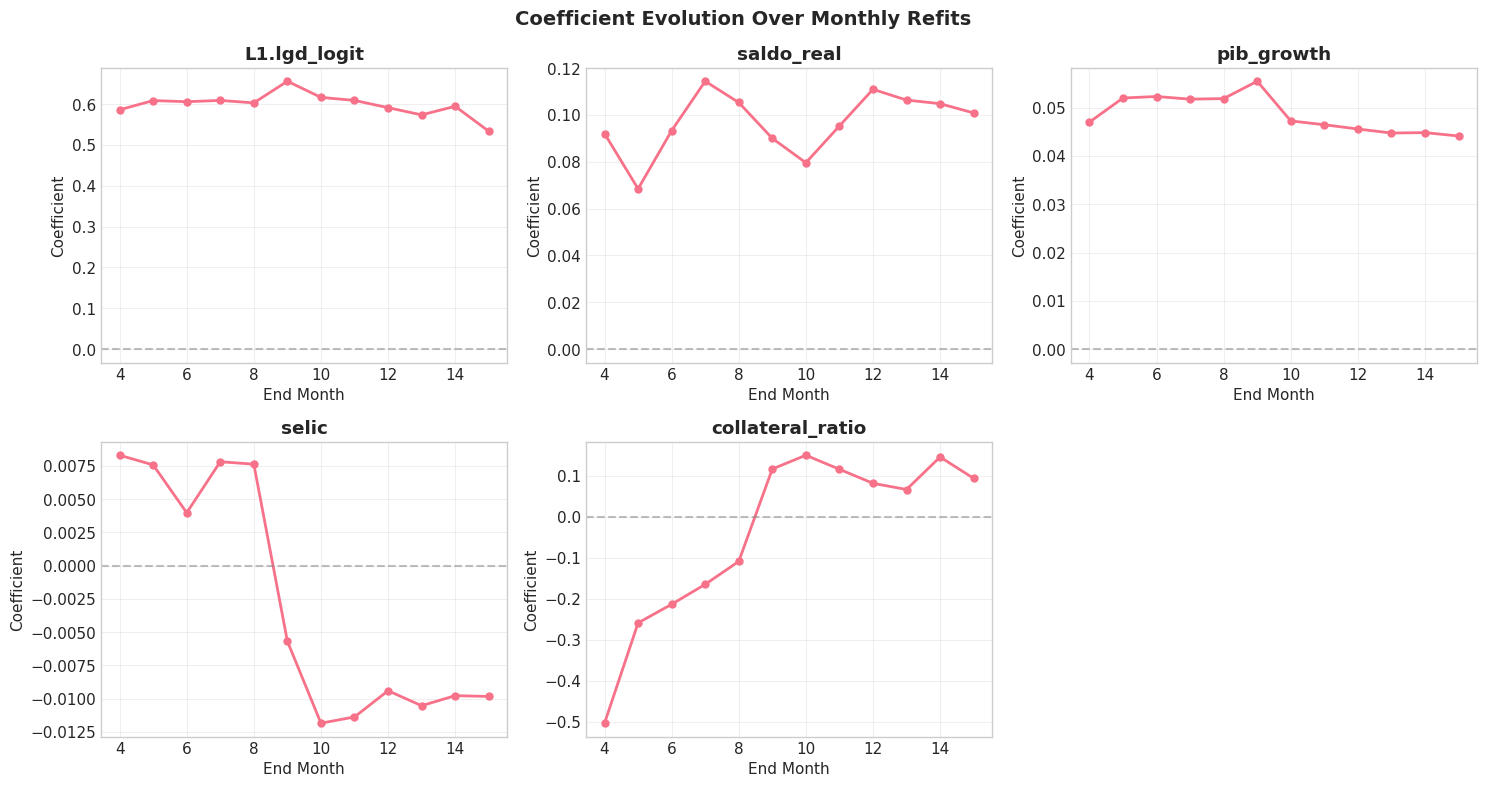

Figure saved.


In [26]:
# Plot coefficient trajectories
coef_cols = [c for c in trajectories.columns if c not in ["month", "nobs"]]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes_flat = axes.flatten()

for i, col in enumerate(coef_cols):
    if i < len(axes_flat):
        ax = axes_flat[i]
        ax.plot(trajectories["month"], trajectories[col], "o-", linewidth=2, markersize=5)
        ax.set_title(col, fontweight="bold")
        ax.set_xlabel("End Month")
        ax.set_ylabel("Coefficient")
        ax.grid(alpha=0.3)
        ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)

# Hide unused axes
for i in range(len(coef_cols), len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.suptitle("Coefficient Evolution Over Monthly Refits", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_coefficient_trajectories.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")

### Interpretation

As more data is added, the coefficients should stabilize. If a coefficient shows large jumps even with substantial data (e.g., 10+ periods), this may signal:
- Structural breaks in the data
- Model misspecification
- Weak instruments

Monitoring coefficient trajectories over time is a key part of model governance in production.

---

## Exercise 4 (Hard): Complete Production Workflow

**Question**: Build a full production workflow: split data, estimate 3 models, predict, compare RMSE/MAE, select best.

### Solution

In [27]:
# Step 1: Split data
train = df_lgd[df_lgd["month"] <= 12].copy()
test = df_lgd[df_lgd["month"] > 12].copy()

print(f"Train: {train.shape[0]} obs (months 1-12)")
print(f"Test:  {test.shape[0]} obs (months 13-15)")

Train: 2400 obs (months 1-12)
Test:  600 obs (months 13-15)


In [28]:
# Step 2 & 3: Create pipelines for 3 model types
pipelines = {}

# PooledOLS
pipelines["PooledOLS"] = PanelPipeline(
    model_class=PooledOLS,
    model_params={
        "formula": "lgd_logit ~ saldo_real + pib_growth + selic + collateral_ratio",
        "entity_col": "contract_id",
        "time_col": "month",
    },
    name="LGD PooledOLS",
)

# FixedEffects
pipelines["FixedEffects"] = PanelPipeline(
    model_class=FixedEffects,
    model_params={
        "formula": "lgd_logit ~ saldo_real + pib_growth + selic + collateral_ratio",
        "entity_col": "contract_id",
        "time_col": "month",
    },
    name="LGD FixedEffects",
)

# DifferenceGMM
pipelines["DifferenceGMM"] = PanelPipeline(
    model_class=DifferenceGMM,
    model_params={
        "dep_var": "lgd_logit",
        "lags": 1,
        "exog_vars": ["saldo_real", "pib_growth", "selic", "collateral_ratio"],
        "id_var": "contract_id",
        "time_var": "month",
        "gmm_max_lag": 3,
        "collapse": True,
        "two_step": True,
        "robust": True,
        "time_dummies": False,
    },
    name="LGD DifferenceGMM",
)

# Fit all
for name, pipe in pipelines.items():
    pipe.fit(train)
    print(f"{name}: fitted ({pipe.results.nobs} obs, {len(pipe.results.params)} params)")

PooledOLS: fitted (2400 obs, 5 params)
FixedEffects: fitted (2400 obs, 4 params)


DifferenceGMM: fitted (2000 obs, 5 params)


In [29]:
# Step 4: Predict on test
y_actual = test["lgd_logit"].values

all_preds = {}
for name, pipe in pipelines.items():
    preds = pipe.predict(test)
    all_preds[name] = preds
    n_valid = np.sum(~np.isnan(preds))
    print(f"{name}: {n_valid}/{len(preds)} valid predictions")

PooledOLS: 600/600 valid predictions
FixedEffects: 600/600 valid predictions
DifferenceGMM: 400/600 valid predictions


In [30]:
# Step 5: Comparison table
results_table = []

for name, preds in all_preds.items():
    # Use only valid (non-NaN) predictions
    mask = ~np.isnan(preds)
    y_true = y_actual[mask]
    y_pred = preds[mask]

    # RMSE
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

    # MAE
    mae = np.mean(np.abs(y_true - y_pred))

    # Direction accuracy (sign of change)
    # Compare sign of actual change vs predicted level relative to mean
    y_mean = y_true.mean()
    dir_acc = np.mean((y_true > y_mean) == (y_pred > y_mean))

    results_table.append(
        {
            "Model": name,
            "N_Valid": mask.sum(),
            "RMSE": rmse,
            "MAE": mae,
            "Direction_Accuracy": dir_acc,
        }
    )

comparison_df = pd.DataFrame(results_table).set_index("Model")
print("Model Comparison:")
display(comparison_df.round(4))

Model Comparison:


,N_Valid,RMSE,MAE,Direction_Accuracy
Model,,,,
PooledOLS,600,0.8431,0.6726,0.5967
FixedEffects,600,0.4861,0.3887,0.8117
DifferenceGMM,400,0.4344,0.3521,0.8425


In [31]:
# Step 6: Select and save the best model (lowest RMSE)
best_model_name = comparison_df["RMSE"].idxmin()
best_pipeline = pipelines[best_model_name]

print(f"Best model: {best_model_name} (RMSE = {comparison_df.loc[best_model_name, 'RMSE']:.4f})")

# Save as production model
prod_path = MODELS_DIR / "ex4_production_model.pkl"
best_pipeline.save(prod_path)
print(f"Production model saved to: {prod_path}")
print(f"File size: {prod_path.stat().st_size / 1024:.1f} KB")

Best model: DifferenceGMM (RMSE = 0.4344)
Production model saved to: ../outputs/models/ex4_production_model.pkl
File size: 19.7 KB


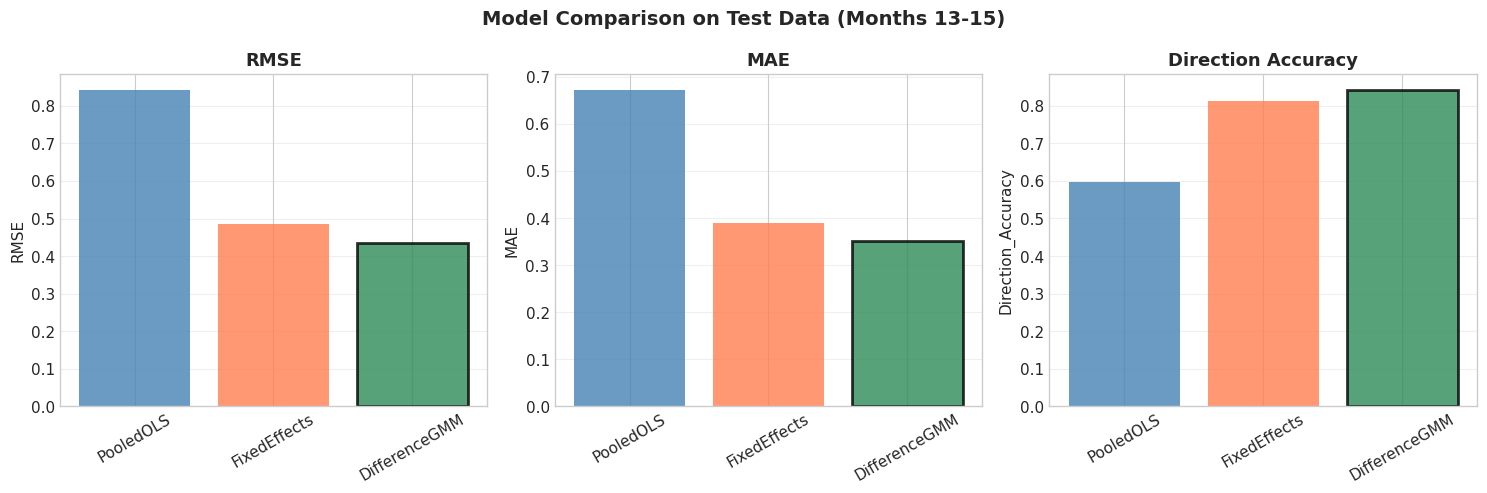

Figure saved.


In [32]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ["RMSE", "MAE", "Direction_Accuracy"]
colors = ["steelblue", "coral", "seagreen"]

for i, metric in enumerate(metrics):
    ax = axes[i]
    bars = ax.bar(comparison_df.index, comparison_df[metric], color=colors, alpha=0.8)
    ax.set_title(metric.replace("_", " "), fontsize=13, fontweight="bold")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(alpha=0.3, axis="y")

    # Highlight best
    if metric == "Direction_Accuracy":
        best_idx = comparison_df[metric].argmax()
    else:
        best_idx = comparison_df[metric].argmin()
    bars[best_idx].set_edgecolor("black")
    bars[best_idx].set_linewidth(2)

plt.suptitle("Model Comparison on Test Data (Months 13-15)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_ex4_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")

### Interpretation

This exercise demonstrates a complete model selection pipeline:

1. **Data splitting** ensures honest out-of-sample evaluation
2. **Multiple model types** account for different assumptions (pooling, fixed effects, dynamics)
3. **Multiple metrics** capture different aspects of predictive quality:
   - RMSE penalizes large errors more heavily
   - MAE gives equal weight to all errors
   - Direction accuracy measures qualitative prediction quality
4. **Saving the best model** as a pipeline ensures the full configuration is preserved

In production, this workflow would run periodically (e.g., quarterly), with the selected model replacing the previous version after passing validation checks.

---

## Summary

In this notebook, we learned:

- **`PanelPipeline`** provides a unified interface for the full model lifecycle
- **Static models** (PooledOLS, FixedEffects) use `fit()` and `predict()`
- **GMM models** additionally support `forecast()` for multi-step predictions
- **`refit()`** re-estimates with new data, and **`compare()`** detects parameter drift
- **`to_dict()`** and **`to_json()`** export configurations for documentation
- Always **validate** before deploying and **monitor** for drift